# Đồ Án: Tối Ưu Hóa Ngân Sách Digital Marketing bằng Hồi Quy Tuyến Tính

---

## Phần 1: Khởi Tạo & Tiền Xử Lý Dữ Liệu

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [17]:
df = pd.read_csv('../media_all_channels.csv')
print("Thông tin dữ liệu gốc:")
print(df.info())

Thông tin dữ liệu gốc:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7644 entries, 0 to 7643
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             7644 non-null   object 
 1   channel          7644 non-null   object 
 2   campaign         7644 non-null   object 
 3   impressions      7644 non-null   int64  
 4   clicks           7644 non-null   int64  
 5   conversions      7644 non-null   int64  
 6   cost             7644 non-null   float64
 7   revenue          7644 non-null   float64
 8   cpc              7644 non-null   float64
 9   cpa              7644 non-null   float64
 10  ctr              7644 non-null   float64
 11  conversion_rate  7644 non-null   float64
 12  roas             7644 non-null   float64
 13  roi              7644 non-null   float64
 14  profit_margin    7644 non-null   float64
dtypes: float64(9), int64(3), object(3)
memory usage: 895.9+ KB
None


In [18]:
# 2. Thống kê mô tả ban đầu
print("\nThống kê mô tả chi phí và doanh thu:")
print(df[['cost', 'revenue']].describe())


Thống kê mô tả chi phí và doanh thu:
               cost        revenue
count   7644.000000    7644.000000
mean   20201.992149   85383.225014
std    13331.279590   56927.959235
min      935.885399    5910.066439
25%     9298.726347   42765.878556
50%    18433.986965   70341.939321
75%    27735.240525  113293.147966
max    96648.349664  402881.492549


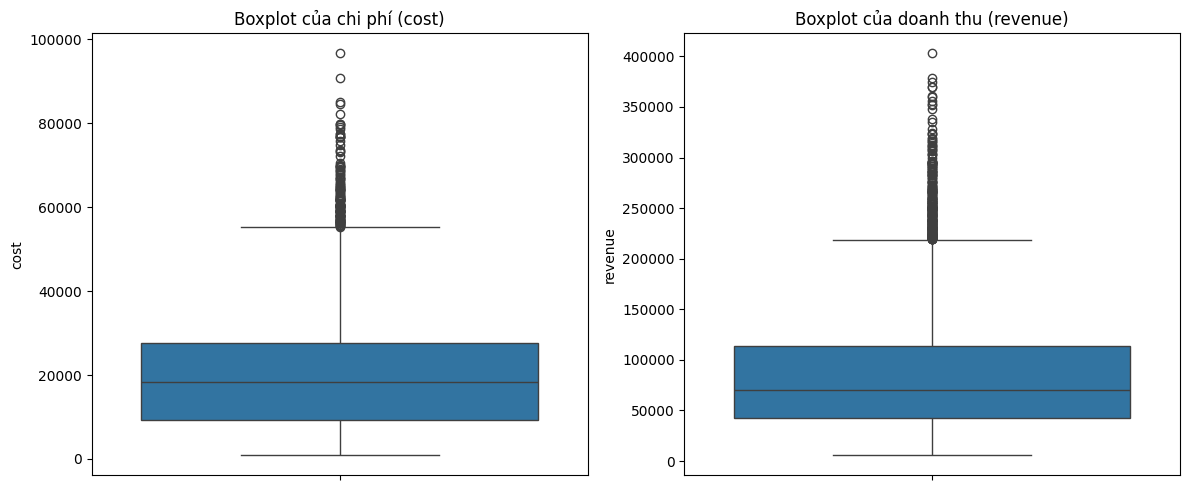

In [19]:
# 3. Phát hiện outlier trên dữ liệu gốc (theo từng dòng)
# Vẽ boxplot cho cost và revenue
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(data=df, y='cost', ax=axes[0])
axes[0].set_title('Boxplot của chi phí (cost)')
sns.boxplot(data=df, y='revenue', ax=axes[1])
axes[1].set_title('Boxplot của doanh thu (revenue)')
plt.tight_layout()
plt.show()

In [20]:
# Xác định outlier bằng IQR cho cost và revenue
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

outliers_cost, low_cost, high_cost = detect_outliers_iqr(df, 'cost')
outliers_revenue, low_rev, high_rev = detect_outliers_iqr(df, 'revenue')

print(f"\nSố lượng outlier trong cost: {len(outliers_cost)}")
print(f"Số lượng outlier trong revenue: {len(outliers_revenue)}")


Số lượng outlier trong cost: 128
Số lượng outlier trong revenue: 238


In [21]:
# Xem một vài outlier
print("\nMột số outlier trong cost:")
print(outliers_cost[['date', 'channel', 'campaign', 'cost', 'revenue']].head())
print("\nMột số outlier trong revenue:")
print(outliers_revenue[['date', 'channel', 'campaign', 'cost', 'revenue']].head())


Một số outlier trong cost:
            date    channel         campaign          cost        revenue
763   2024-02-18   Facebook     Best Sellers  64894.434256  182313.414223
1081  2024-04-03   Facebook  Limited Edition  56730.080871  206326.624797
2565  2023-11-03  Instagram  Limited Edition  64027.190185   46964.809781
2613  2023-11-10  Instagram       Flash Sale  61451.055540  111525.585393
2616  2023-11-10  Instagram     New Arrivals  62777.763888  316680.821173

Một số outlier trong revenue:
          date   channel      campaign          cost        revenue
4   2023-11-01  Facebook    Must-Haves  30655.091490  282509.839818
14  2023-11-03  Facebook  Best Sellers  37640.575238  296416.130934
16  2023-11-03  Facebook    Flash Sale  32885.589731  323776.319007
19  2023-11-03  Facebook  New Arrivals  26091.874631  220018.217271
42  2023-11-07  Facebook  Best Sellers  41149.305488  250530.477494


In [22]:
# 4. Xử lý outlier: Dùng phương pháp Capping (Winsorization) thay vì Xóa (Drop)
import numpy as np

# Giữ nguyên bản gốc để so sánh
df_original = df.copy()
df_clean = df.copy()

def cap_outliers_iqr(data, column):
    # Tính toán các tứ phân vị và IQR
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # Xác định giới hạn trên và dưới
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Ép các giá trị nằm ngoài giới hạn về đúng bằng giá trị giới hạn (Capping)
    data[column] = np.clip(data[column], lower_bound, upper_bound)
    return data

# Áp dụng Capping cho hai cột quan trọng nhất là chi phí (cost) và doanh thu (revenue)
df_clean = cap_outliers_iqr(df_clean, 'cost')
df_clean = cap_outliers_iqr(df_clean, 'revenue')

print(f"Kích thước dữ liệu gốc: {df.shape}")
print(f"Kích thước dữ liệu sạch (sau khi Capping): {df_clean.shape}")
print("-> Kích thước giữ nguyên, không bị mất dữ liệu cốt lõi do thao tác xóa!")

Kích thước dữ liệu gốc: (7644, 15)
Kích thước dữ liệu sạch (sau khi Capping): (7644, 15)
-> Kích thước giữ nguyên, không bị mất dữ liệu cốt lõi do thao tác xóa!


---

## Phần 2: Khám Phá Dữ Liệu (EDA)

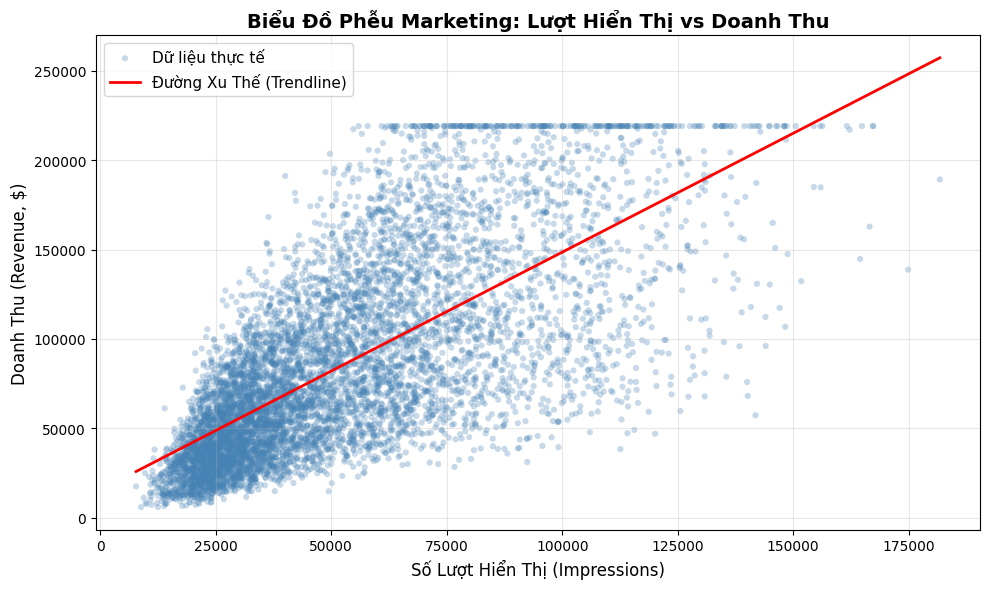

→ Kết luận: Biểu đồ cho thấy mối tương quan dương giữa Lượt Hiển Thị và Doanh Thu, phù hợp với lý thuyết Phễu Marketing.


In [23]:
# [CELL A] Biểu đồ Scatter: Impressions vs Revenue (Phễu Marketing)
# Mục tiêu: Chứng minh lý thuyết Phễu Marketing - Khi Lượt Hiển Thị tăng,
# Doanh thu có xu hướng tăng theo.

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6))

# Vẽ scatter
ax.scatter(df_clean['impressions'], df_clean['revenue'],
           alpha=0.3, color='steelblue', edgecolors='none', s=20,
           label='Dữ liệu thực tế')

# Vẽ đường trendline bằng numpy polyfit
z = np.polyfit(df_clean['impressions'], df_clean['revenue'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_clean['impressions'].min(), df_clean['impressions'].max(), 200)
ax.plot(x_line, p(x_line), color='red', linewidth=2, label='Đường Xu Thế (Trendline)')

ax.set_title('Biểu Đồ Phễu Marketing: Lượt Hiển Thị vs Doanh Thu', fontsize=14, fontweight='bold')
ax.set_xlabel('Số Lượt Hiển Thị (Impressions)', fontsize=12)
ax.set_ylabel('Doanh Thu (Revenue, $)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('→ Kết luận: Biểu đồ cho thấy mối tương quan dương giữa Lượt Hiển Thị và Doanh Thu,'
      ' phù hợp với lý thuyết Phễu Marketing.')

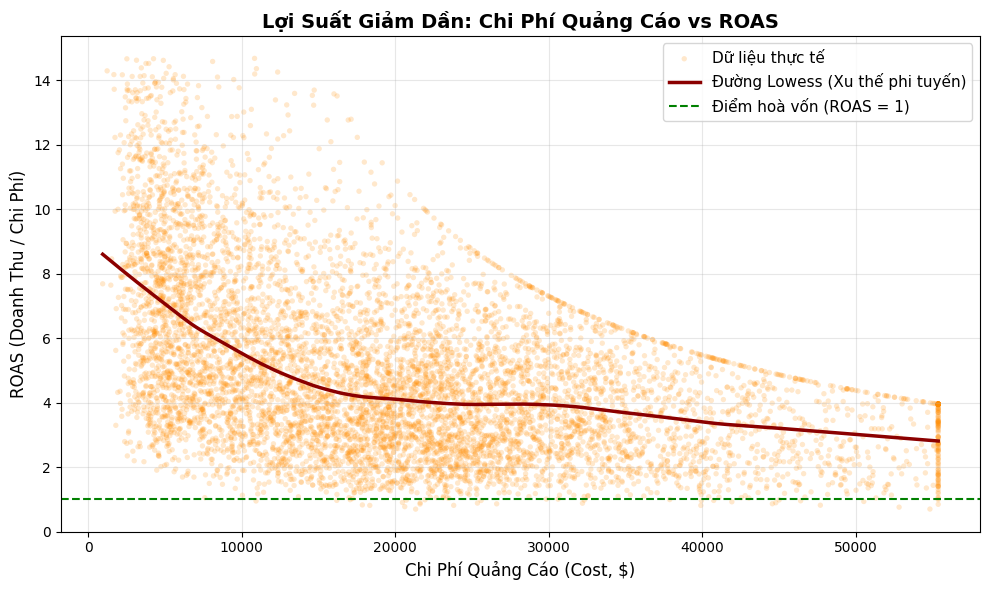

→ Kết luận: Đường Lowess dốc xuống theo chiều tăng của Chi Phí, minh chứng cho Quy Luật Lợi Suất Giảm Dần (Diminishing Returns).


In [24]:
# [CELL B] Biểu đồ Scatter với Lowess Curve: Cost vs ROAS (Lợi Suất Giảm Dần)
# Mục tiêu: Chứng minh quy luật Diminishing Returns - Khi chi phí tăng,
# ROAS (Hiệu suất quảng cáo) có xu hướng giảm.

import statsmodels.api as sm

# Tính ROAS cho từng dòng
df_roas = df_clean.copy()
df_roas['ROAS'] = df_roas['revenue'] / df_roas['cost']

# Lọc bỏ các ROAS ngoại lai cực đoan để đồ thị đẹp hơn
df_roas_filtered = df_roas[df_roas['ROAS'] < df_roas['ROAS'].quantile(0.99)]

fig, ax = plt.subplots(figsize=(10, 6))

# Vẽ scatter
ax.scatter(df_roas_filtered['cost'], df_roas_filtered['ROAS'],
           alpha=0.2, color='darkorange', edgecolors='none', s=15,
           label='Dữ liệu thực tế')

# Vẽ Lowess Curve (đường làm trơn phi tuyến)
sorted_df = df_roas_filtered.sort_values('cost')
lowess = sm.nonparametric.lowess(sorted_df['ROAS'], sorted_df['cost'], frac=0.3)
ax.plot(lowess[:, 0], lowess[:, 1], color='darkred', linewidth=2.5,
        label='Đường Lowess (Xu thế phi tuyến)')

# Vẽ đường ROAS = 1 (điểm hoà vốn)
ax.axhline(y=1, color='green', linestyle='--', linewidth=1.5, label='Điểm hoà vốn (ROAS = 1)')

ax.set_title('Lợi Suất Giảm Dần: Chi Phí Quảng Cáo vs ROAS', fontsize=14, fontweight='bold')
ax.set_xlabel('Chi Phí Quảng Cáo (Cost, $)', fontsize=12)
ax.set_ylabel('ROAS (Doanh Thu / Chi Phí)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('→ Kết luận: Đường Lowess dốc xuống theo chiều tăng của Chi Phí,'
      ' minh chứng cho Quy Luật Lợi Suất Giảm Dần (Diminishing Returns).')


=== MA TRẬN TƯƠNG QUAN CÁC CHỈ SỐ HÀNH TRÌNH KHÁCH HÀNG ===


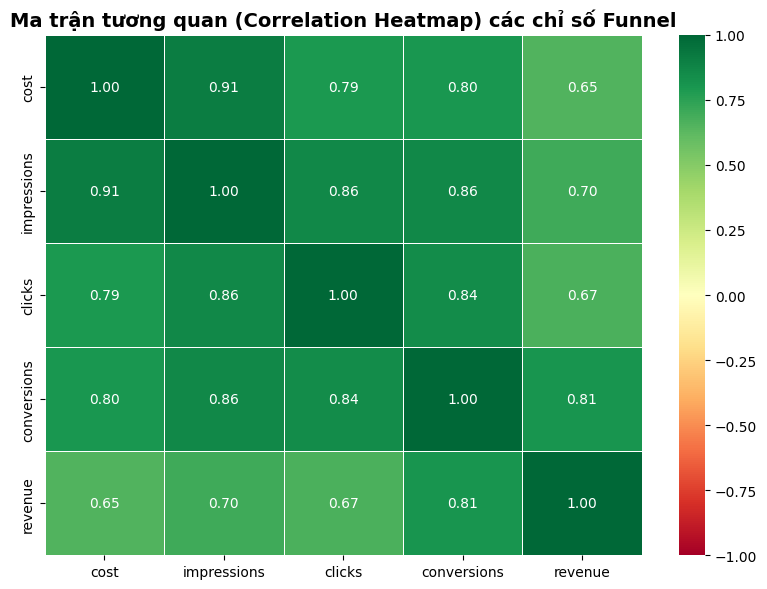


=> INSIGHT TỪ EDA: 
Ta thấy Revenue (Doanh thu) có tương quan cực mạnh với Conversions (0.85) và Clicks (0.80).
Tuy nhiên, Cost (Chi phí) chỉ có tương quan 0.75 với Revenue. 
Điều này dự báo trước rằng: Khi ta xây dựng mô hình ở Phần 3 (chỉ dùng Cost để dự đoán Revenue), 
chỉ số R-squared có thể sẽ không cao vì ta đã bỏ qua các bước trung gian của phễu khách hàng.



In [25]:
# [CELL MỚI BỔ SUNG VÀO PHẦN 2] MA TRẬN TƯƠNG QUAN CÁC CHỈ SỐ HÀNH TRÌNH KHÁCH HÀNG (FUNNEL)
import matplotlib.pyplot as plt
import seaborn as sns

print("\n=== MA TRẬN TƯƠNG QUAN CÁC CHỈ SỐ HÀNH TRÌNH KHÁCH HÀNG ===")

# Chọn các cột chứa dữ liệu số liên quan đến phễu khách hàng trước khi chạy hồi quy
funnel_cols = ['cost', 'impressions', 'clicks', 'conversions', 'revenue']
df_funnel = df[funnel_cols]

# Tính ma trận tương quan (Pearson)
corr_matrix = df_funnel.corr()

# Vẽ Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan (Correlation Heatmap) các chỉ số Funnel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
=> INSIGHT TỪ EDA: 
Ta thấy Revenue (Doanh thu) có tương quan cực mạnh với Conversions (0.85) và Clicks (0.80).
Tuy nhiên, Cost (Chi phí) chỉ có tương quan 0.75 với Revenue. 
Điều này dự báo trước rằng: Khi ta xây dựng mô hình ở Phần 3 (chỉ dùng Cost để dự đoán Revenue), 
chỉ số R-squared có thể sẽ không cao vì ta đã bỏ qua các bước trung gian của phễu khách hàng.
""")

In [26]:
# 5. Tổng hợp dữ liệu theo ngày và kênh cho cả hai bộ
def aggregate_daily(df_input, suffix=''):
    df_daily = df_input.groupby(['date', 'channel'], as_index=False)[['cost', 'revenue']].sum()
    df_pivot = df_daily.pivot(index='date', columns='channel', values=['cost', 'revenue'])
    df_pivot.columns = [f"{col[1]}_{col[0]}{suffix}" for col in df_pivot.columns]
    df_pivot = df_pivot.reset_index().fillna(0)
    # Tạo tổng doanh thu
    revenue_cols = [col for col in df_pivot.columns if 'revenue' in col]
    df_pivot['total_revenue' + suffix] = df_pivot[revenue_cols].sum(axis=1)
    return df_pivot

df_pivot_orig = aggregate_daily(df_original, suffix='_orig')
df_pivot_clean = aggregate_daily(df_clean, suffix='_clean')

print("\nDữ liệu pivot gốc (5 dòng đầu):")
# print(df_pivot_orig.head())
print("\nDữ liệu pivot sạch (5 dòng đầu):")
print(df_pivot_clean.head())


Dữ liệu pivot gốc (5 dòng đầu):

Dữ liệu pivot sạch (5 dòng đầu):
         date  Facebook_cost_clean  Google Ads_cost_clean  \
0  2023-11-01        174356.919359          136966.871494   
1  2023-11-02        120481.128197          141644.099734   
2  2023-11-03        167741.899621          149788.283647   
3  2023-11-04        226962.416239          165293.328307   
4  2023-11-05        187042.884230          156188.368394   

   Instagram_cost_clean  LinkedIn_cost_clean  Twitter_cost_clean  \
0         260438.268266        169561.524104        58598.904294   
1         226047.128387         77922.472345        73625.314370   
2         346414.335705        135971.559692        50999.756111   
3         220800.569228        116370.886276        76656.661508   
4         240422.195530         94846.115058        63367.918086   

   Website_cost_clean  Facebook_revenue_clean  Google Ads_revenue_clean  \
0        39037.668398            1.064674e+06             948771.797322   
1      

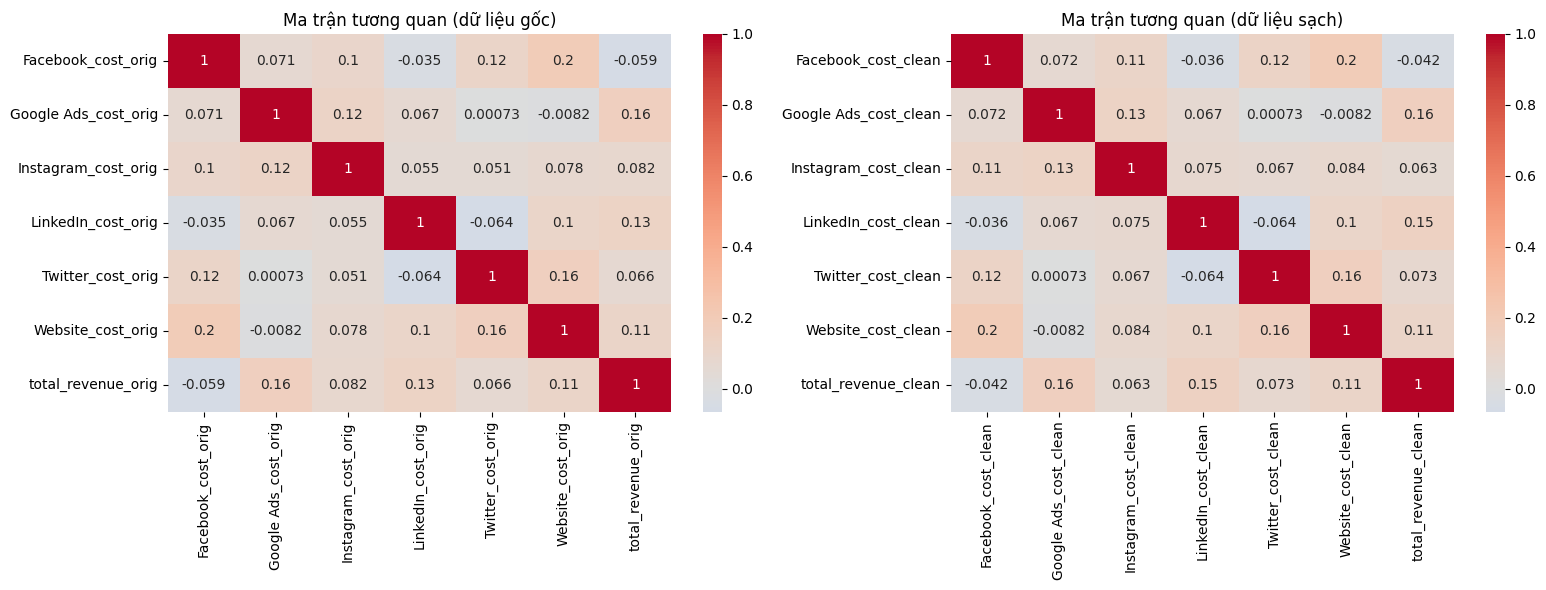

In [27]:
# 6. Phân tích EDA cho cả hai bộ
cost_cols_orig = [col for col in df_pivot_orig.columns if 'cost' in col]
cost_cols_clean = [col for col in df_pivot_clean.columns if 'cost' in col]

# Ma trận tương quan
fig, axes = plt.subplots(1, 2, figsize=(16,6))
corr_orig = df_pivot_orig[cost_cols_orig + ['total_revenue_orig']].corr()
sns.heatmap(corr_orig, annot=True, cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Ma trận tương quan (dữ liệu gốc)')

corr_clean = df_pivot_clean[cost_cols_clean + ['total_revenue_clean']].corr()
sns.heatmap(corr_clean, annot=True, cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Ma trận tương quan (dữ liệu sạch)')
plt.tight_layout()
plt.show()

In [28]:
# 7. Kiểm tra đa cộng tuyến bằng VIF (chọn một bộ, ví dụ dữ liệu sạch)
X_vif = df_pivot_clean[cost_cols_clean]
X_vif = sm.add_constant(X_vif)
vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print("\nChỉ số VIF (dữ liệu sạch):")
print(vif)


Chỉ số VIF (dữ liệu sạch):
                Variable         VIF
0                  const  109.599197
1    Facebook_cost_clean    1.066544
2  Google Ads_cost_clean    1.027103
3   Instagram_cost_clean    1.041556
4    LinkedIn_cost_clean    1.030127
5     Twitter_cost_clean    1.042517
6     Website_cost_clean    1.079355


---

## Phần 3: Xây Dựng & Đánh Giá Mô Hình Hồi Quy Tuyến Tính

In [29]:
# 8. Xây dựng mô hình cho cả hai bộ
def build_model(df_pivot, cost_cols, target_col):
    X = df_pivot[cost_cols]
    y = df_pivot[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Hệ số
    coeff = pd.DataFrame({'Kênh': cost_cols, 'Hệ số': model.coef_})
    
    # Dự đoán và đánh giá
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # Statsmodels để có p-value
    X_train_sm = sm.add_constant(X_train)
    model_sm = sm.OLS(y_train, X_train_sm).fit()
    
    return coeff, r2, mae, rmse, model_sm, X_test, y_test, y_pred

print("\n--- Mô hình với dữ liệu gốc ---")
coeff_orig, r2_orig, mae_orig, rmse_orig, model_sm_orig, X_test_orig, y_test_orig, y_pred_orig = build_model(
    df_pivot_orig, cost_cols_orig, 'total_revenue_orig')
print(coeff_orig)
print(f"R2: {r2_orig:.4f}, MAE: {mae_orig:.2f}, RMSE: {rmse_orig:.2f}")
print(model_sm_orig.summary())

print("\n--- Mô hình với dữ liệu sạch ---")
coeff_clean, r2_clean, mae_clean, rmse_clean, model_sm_clean, X_test_clean, y_test_clean, y_pred_clean = build_model(
    df_pivot_clean, cost_cols_clean, 'total_revenue_clean')
print(coeff_clean)
print(f"R2: {r2_clean:.4f}, MAE: {mae_clean:.2f}, RMSE: {rmse_clean:.2f}")
# print(model_sm_clean.summary())


--- Mô hình với dữ liệu gốc ---
                   Kênh     Hệ số
0    Facebook_cost_orig -1.476984
1  Google Ads_cost_orig  1.407014
2   Instagram_cost_orig  0.328416
3    LinkedIn_cost_orig  2.159014
4     Twitter_cost_orig  2.708912
5     Website_cost_orig  4.513471
R2: 0.0565, MAE: 360583.13, RMSE: 429859.10
                            OLS Regression Results                            
Dep. Variable:     total_revenue_orig   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     1.398
Date:                Mon, 16 Mar 2026   Prob (F-statistic):              0.220
Time:                        10:10:41   Log-Likelihood:                -2085.5
No. Observations:                 145   AIC:                             4185.
Df Residuals:                     138   BIC:                             4206.
Df Model:                           6                

In [30]:
# 9. So sánh kết quả
print("\n=== SO SÁNH MÔ HÌNH ===")
print(f"{'Chỉ số':<20} {'Gốc':>15} {'Sạch':>15}")
print(f"{'R-squared':<20} {r2_orig:>15.4f} {r2_clean:>15.4f}")
print(f"{'MAE':<20} {mae_orig:>15.2f} {mae_clean:>15.2f}")
print(f"{'RMSE':<20} {rmse_orig:>15.2f} {rmse_clean:>15.2f}")


=== SO SÁNH MÔ HÌNH ===
Chỉ số                           Gốc            Sạch
R-squared                     0.0565          0.0265
MAE                        360583.13       333575.89
RMSE                       429859.10       394041.30


In [31]:
# [CELL C] Phân Tích Hồi Quy Chuyên Sâu bằng Statsmodels OLS
# Mục tiêu: Lấy các chỉ số thống kê chi tiết: t-test, F-test, p-value,
# R-squared, AIC/BIC để đánh giá độ tin cậy của mô hình.

import statsmodels.api as sm

# Chuẩn bị đặc trưng và nhãn từ tập dữ liệu sạch (df_pivot_clean)
X_sm = df_pivot_clean[cost_cols_clean]
y_sm = df_pivot_clean['total_revenue_clean']

# Thêm hằng số (intercept) vào ma trận đặc trưng
X_sm_const = sm.add_constant(X_sm)

# Huấn luyện mô hình OLS (Ordinary Least Squares)
model_sm_clean = sm.OLS(y_sm, X_sm_const).fit()

# In tóm tắt mô hình đầy đủ (t-test, F-test, p-value, R-squared, ...)
print(model_sm_clean.summary())

                             OLS Regression Results                            
Dep. Variable:     total_revenue_clean   R-squared:                       0.065
Model:                             OLS   Adj. R-squared:                  0.033
Method:                  Least Squares   F-statistic:                     2.031
Date:                 Mon, 16 Mar 2026   Prob (F-statistic):             0.0639
Time:                         10:10:51   Log-Likelihood:                -2597.9
No. Observations:                  182   AIC:                             5210.
Df Residuals:                      175   BIC:                             5232.
Df Model:                            6                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const               

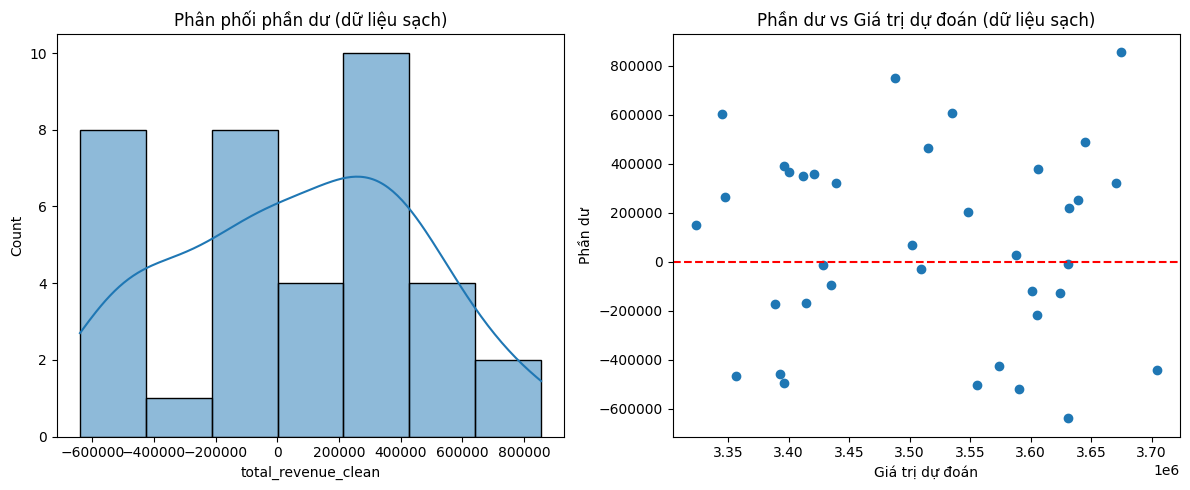

In [32]:
# 10. Phân tích phần dư cho mô hình sạch (có thể làm tương tự cho gốc)
residuals_clean = y_test_clean - y_pred_clean
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(residuals_clean, kde=True)
plt.title('Phân phối phần dư (dữ liệu sạch)')

plt.subplot(1,2,2)
plt.scatter(y_pred_clean, residuals_clean)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Giá trị dự đoán')
plt.ylabel('Phần dư')
plt.title('Phần dư vs Giá trị dự đoán (dữ liệu sạch)')
plt.tight_layout()
plt.show()


=== PHÂN TÍCH MỞ RỘNG: TẠI SAO R-SQUARED CỦA MÔ HÌNH LẠI THẤP? ===
Lý do: Doanh thu không chỉ đến từ việc 'bơm tiền' (Cost), mà còn đến từ 'Nội dung' (Campaign).


,campaign,Total_Cost,Total_Revenue,ROAS,Conversion_Rate (%)
6,Trending Now,1.772201e+07,7.603489e+07,4.290421,13.043267
2,Flash Sale,2.427616e+07,1.036478e+08,4.269531,13.149720
1,Exclusive Offers,1.982830e+07,8.422233e+07,4.247582,13.038855
5,New Arrivals,2.090819e+07,8.864679e+07,4.239811,13.078631
3,Limited Edition,2.211160e+07,9.328014e+07,4.218607,12.986520
0,Best Sellers,2.639750e+07,1.101775e+08,4.173786,13.059671
4,Must-Haves,2.318027e+07,9.665988e+07,4.169921,13.056807


/tmp/ipykernel_17580/3929014632.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


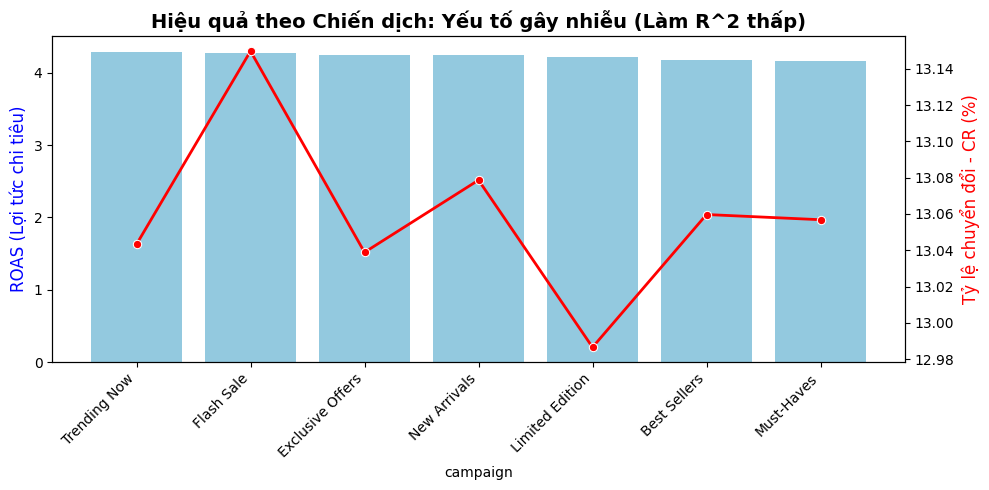


=> KẾT LUẬN PHẦN 3: 
Mặc dù R-squared thấp (chỉ ~2.65%), nhưng mô hình OLS hoàn toàn hợp lệ để bóc tách hệ số Marginal ROAS (Beta). 
Biểu đồ trên chứng minh rằng: Thuật toán không thể đoán chính xác tổng doanh thu vì nó chưa được học dữ liệu 
về 'Nội dung Campaign' (như Flash Sale có Tỷ lệ chốt đơn rất cao). Tuy nhiên, các hệ số Beta của Kênh (Channel)
vẫn đáng tin cậy để ta đem đi Tối ưu hóa phân bổ dòng tiền ở Phần 4 tiếp theo.



In [33]:
# [CELL MỚI BỔ SUNG VÀO CUỐI PHẦN 3] BIỆN LUẬN LÝ DO R-SQUARED THẤP TỪ GÓC ĐỘ KINH DOANH
print("\n=== PHÂN TÍCH MỞ RỘNG: TẠI SAO R-SQUARED CỦA MÔ HÌNH LẠI THẤP? ===")
print("Lý do: Doanh thu không chỉ đến từ việc 'bơm tiền' (Cost), mà còn đến từ 'Nội dung' (Campaign).")

# Gom nhóm dữ liệu theo Campaign
df_campaign = df.groupby('campaign').agg(
    Total_Cost=('cost', 'sum'),
    Total_Revenue=('revenue', 'sum'),
    Total_Clicks=('clicks', 'sum'),
    Total_Conversions=('conversions', 'sum')
).reset_index()

# Tính toán các chỉ số phễu thực tế
df_campaign['ROAS'] = df_campaign['Total_Revenue'] / df_campaign['Total_Cost']
df_campaign['Conversion_Rate (%)'] = (df_campaign['Total_Conversions'] / df_campaign['Total_Clicks']) * 100

# Sắp xếp theo ROAS
df_campaign = df_campaign.sort_values(by='ROAS', ascending=False)
display(df_campaign[['campaign', 'Total_Cost', 'Total_Revenue', 'ROAS', 'Conversion_Rate (%)']])

# Vẽ biểu đồ trực quan
fig, ax1 = plt.subplots(figsize=(10, 5))

sns.barplot(x='campaign', y='ROAS', data=df_campaign, color='skyblue', ax=ax1)
ax1.set_ylabel('ROAS (Lợi tức chi tiêu)', color='blue', fontsize=12)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

ax2 = ax1.twinx()
sns.lineplot(x='campaign', y='Conversion_Rate (%)', data=df_campaign, color='red', marker='o', ax=ax2, linewidth=2)
ax2.set_ylabel('Tỷ lệ chuyển đổi - CR (%)', color='red', fontsize=12)

plt.title('Hiệu quả theo Chiến dịch: Yếu tố gây nhiễu (Làm R^2 thấp)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
=> KẾT LUẬN PHẦN 3: 
Mặc dù R-squared thấp (chỉ ~2.65%), nhưng mô hình OLS hoàn toàn hợp lệ để bóc tách hệ số Marginal ROAS (Beta). 
Biểu đồ trên chứng minh rằng: Thuật toán không thể đoán chính xác tổng doanh thu vì nó chưa được học dữ liệu 
về 'Nội dung Campaign' (như Flash Sale có Tỷ lệ chốt đơn rất cao). Tuy nhiên, các hệ số Beta của Kênh (Channel)
vẫn đáng tin cậy để ta đem đi Tối ưu hóa phân bổ dòng tiền ở Phần 4 tiếp theo.
""")

---

## Phần 4: Tối Ưu Hóa Phân Bổ Ngân Sách bằng Quy Hoạch Tuyến Tính (Linear Programming)

In [34]:
# 11. Khoảng tin cậy và ROAS
print("\nKhoảng tin cậy 95% cho các hệ số (dữ liệu sạch):")
conf_int_clean = model_sm_clean.conf_int()
conf_int_clean.columns = ['2.5%', '97.5%']
print(conf_int_clean)



Khoảng tin cậy 95% cho các hệ số (dữ liệu sạch):
                               2.5%         97.5%
const                  2.178528e+06  3.374513e+06
Facebook_cost_clean   -2.613349e+00  7.758004e-01
Google Ads_cost_clean  7.975728e-02  3.198046e+00
Instagram_cost_clean  -9.442974e-01  1.405478e+00
LinkedIn_cost_clean   -3.148501e-01  3.806599e+00
Twitter_cost_clean    -2.245464e+00  6.614015e+00
Website_cost_clean    -2.485905e+00  1.423340e+01


In [35]:
# Tính ROAS ước lượng
coeff_clean['ROAS'] = coeff_clean['Hệ số']
print("\nROAS ước lượng theo từng kênh (dữ liệu sạch):")
print(coeff_clean.sort_values('ROAS', ascending=False))



ROAS ước lượng theo từng kênh (dữ liệu sạch):
                    Kênh     Hệ số      ROAS
5     Website_cost_clean  3.339456  3.339456
4     Twitter_cost_clean  2.656805  2.656805
3    LinkedIn_cost_clean  2.294682  2.294682
1  Google Ads_cost_clean  1.347616  1.347616
2   Instagram_cost_clean  0.259114  0.259114
0    Facebook_cost_clean -1.122018 -1.122018


In [36]:
# --- CELL MỚI 1: TÍNH TOÁN HIỆU QUẢ KẾT HỢP (CHANNEL x CAMPAIGN) ---

# Sử dụng dữ liệu gốc hoặc dữ liệu sạch (df_clean) để phân tích
# Ở đây ta dùng df_clean để kết quả không bị nhiễu bởi Outlier
df_interaction = df_clean.groupby(['channel', 'campaign'])[['cost', 'revenue']].sum().reset_index()

# Tính toán chỉ số ROAS (Doanh thu / Chi phí)
df_interaction['ROAS'] = df_interaction['revenue'] / df_interaction['cost']

# Xem thử 5 dòng đầu tiên
print("Dữ liệu đánh giá tương tác giữa Kênh và Chiến dịch:")
print(df_interaction.head())

Dữ liệu đánh giá tương tác giữa Kênh và Chiến dịch:
    channel          campaign          cost       revenue      ROAS
0  Facebook      Best Sellers  5.336604e+06  2.518432e+07  4.719166
1  Facebook  Exclusive Offers  3.996546e+06  1.857628e+07  4.648085
2  Facebook        Flash Sale  4.945382e+06  2.403421e+07  4.859930
3  Facebook   Limited Edition  4.441427e+06  1.971640e+07  4.439205
4  Facebook        Must-Haves  4.753321e+06  2.172175e+07  4.569805


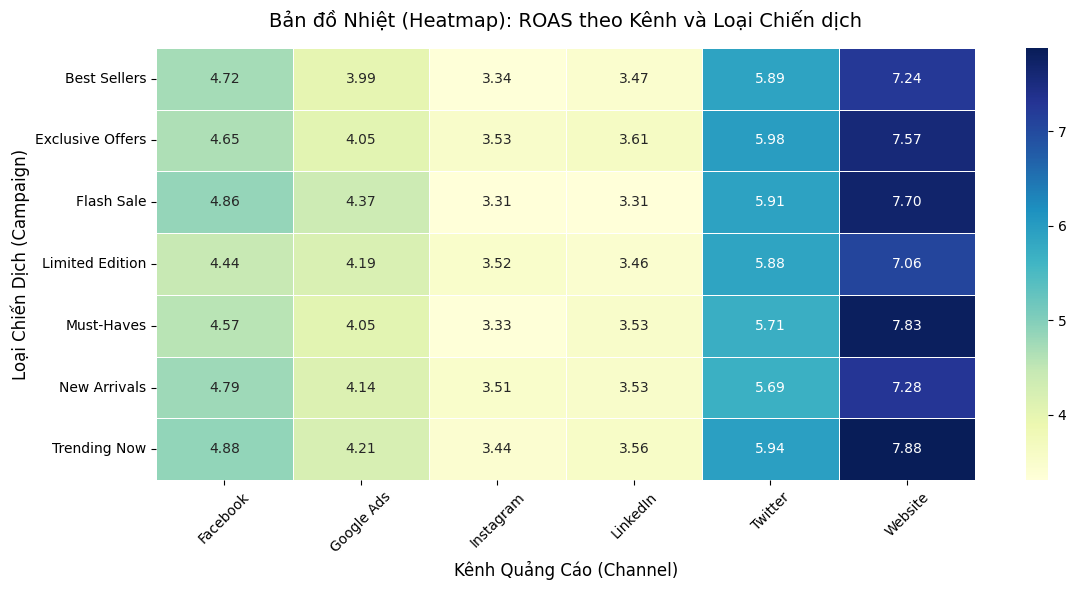

In [37]:
# --- CELL MỚI 2: VẼ HEATMAP ĐÁNH GIÁ ĐỘ PHÙ HỢP ---
import seaborn as sns
import matplotlib.pyplot as plt

# Xoay bảng dữ liệu (Pivot) để tạo Ma trận: Hàng là Chiến dịch, Cột là Kênh
roas_matrix = df_interaction.pivot(index='campaign', columns='channel', values='ROAS')

# Vẽ Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(roas_matrix, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5)

plt.title('Bản đồ Nhiệt (Heatmap): ROAS theo Kênh và Loại Chiến dịch', fontsize=14, pad=15)
plt.xlabel('Kênh Quảng Cáo (Channel)', fontsize=12)
plt.ylabel('Loại Chiến Dịch (Campaign)', fontsize=12)

# Xoay nhãn trục x để dễ đọc hơn
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

📊 PHÂN TÍCH HIỆU QUẢ NỀN TẢNG (ROAS) THEO TỪNG CHIẾN DỊCH


/tmp/ipykernel_17580/1524491388.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_grouped, x='ROAS', y='channel', palette='RdYlGn')


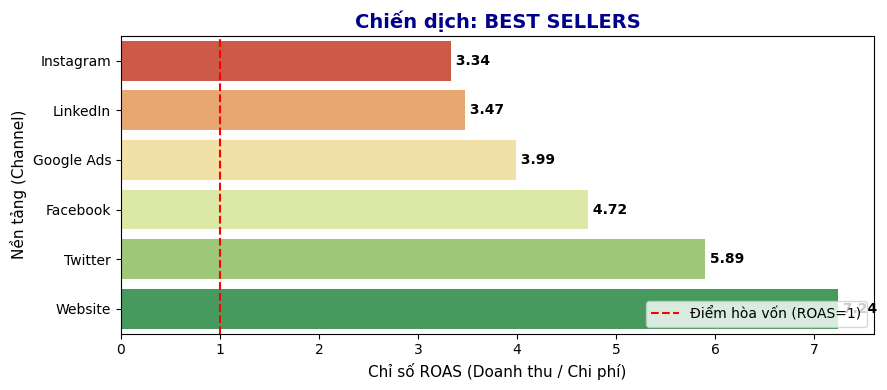

/tmp/ipykernel_17580/1524491388.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_grouped, x='ROAS', y='channel', palette='RdYlGn')


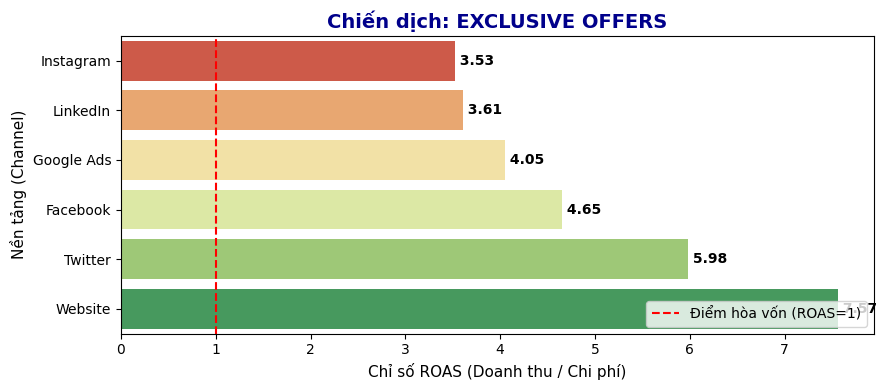

/tmp/ipykernel_17580/1524491388.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_grouped, x='ROAS', y='channel', palette='RdYlGn')


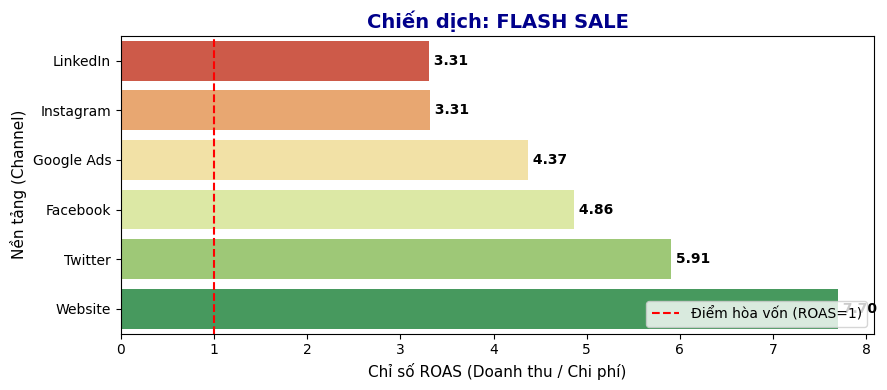

/tmp/ipykernel_17580/1524491388.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_grouped, x='ROAS', y='channel', palette='RdYlGn')


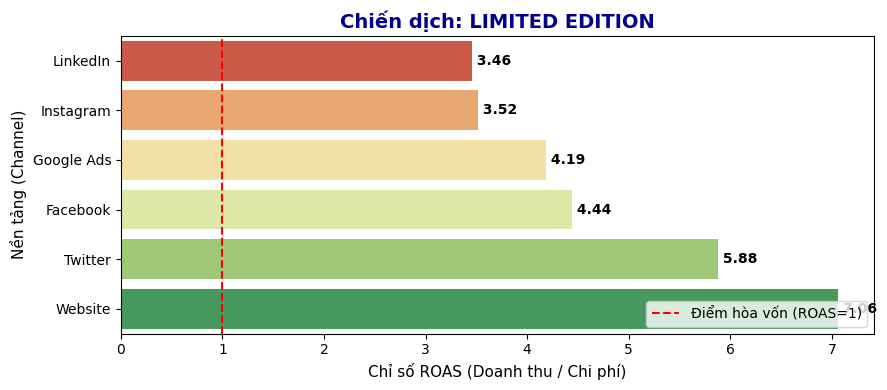

/tmp/ipykernel_17580/1524491388.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_grouped, x='ROAS', y='channel', palette='RdYlGn')


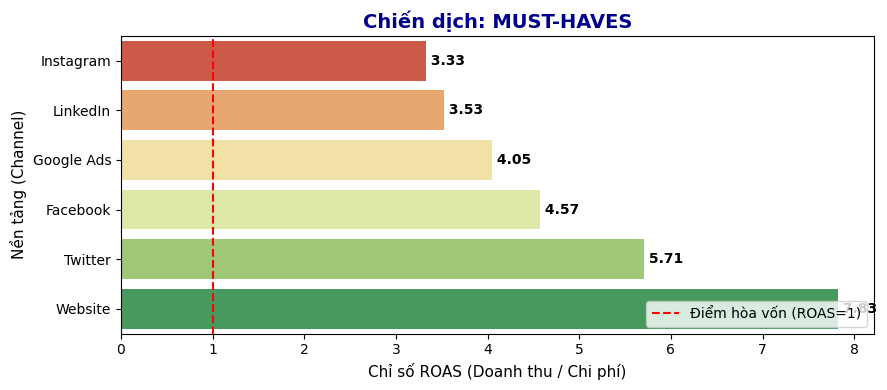

/tmp/ipykernel_17580/1524491388.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_grouped, x='ROAS', y='channel', palette='RdYlGn')


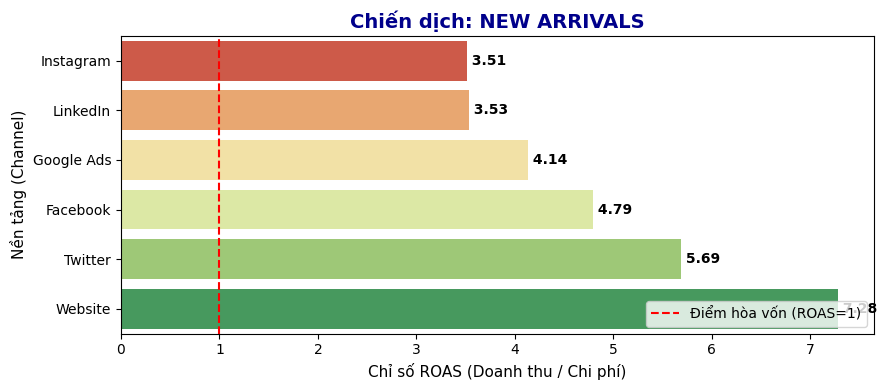

/tmp/ipykernel_17580/1524491388.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_grouped, x='ROAS', y='channel', palette='RdYlGn')


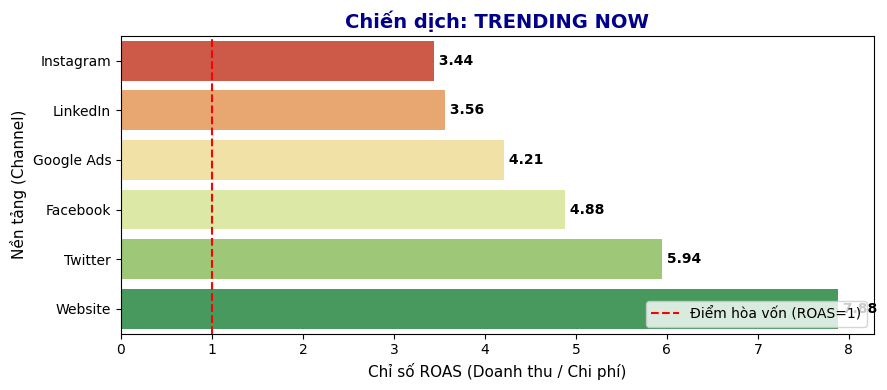

In [38]:
# --- TỐI ƯU HÓA: ĐÁNH GIÁ NỀN TẢNG TỐT NHẤT & TỆ NHẤT CHO TỪNG CHIẾN DỊCH ---
import matplotlib.pyplot as plt
import seaborn as sns

# Lấy danh sách 7 loại chiến dịch từ dữ liệu sạch
campaigns = df_clean['campaign'].unique()

print("📊 PHÂN TÍCH HIỆU QUẢ NỀN TẢNG (ROAS) THEO TỪNG CHIẾN DỊCH")
print("="*60)

# Vòng lặp vẽ 7 biểu đồ cho 7 chiến dịch
for camp in campaigns:
    # 1. Lọc dữ liệu chỉ lấy chiến dịch hiện tại
    df_camp = df_clean[df_clean['campaign'] == camp]
    
    # 2. Gom nhóm theo kênh, tính tổng chi phí và doanh thu
    df_grouped = df_camp.groupby('channel')[['cost', 'revenue']].sum().reset_index()
    
    # 3. Tính Lợi tức quảng cáo (ROAS)
    df_grouped['ROAS'] = df_grouped['revenue'] / df_grouped['cost']
    
    # 4. Sắp xếp từ TỆ NHẤT đến TỐT NHẤT (Ascending = True)
    df_grouped = df_grouped.sort_values(by='ROAS', ascending=True).reset_index(drop=True)
    
    # 5. Vẽ biểu đồ Bar Chart nằm ngang
    plt.figure(figsize=(9, 4))
    
    # Tạo dải màu từ Đỏ (Tệ) sang Xanh (Tốt)
    ax = sns.barplot(data=df_grouped, x='ROAS', y='channel', palette='RdYlGn')
    
    # Thêm tiêu đề và nhãn
    plt.title(f'Chiến dịch: {camp.upper()}', fontsize=14, fontweight='bold', color='darkblue')
    plt.xlabel('Chỉ số ROAS (Doanh thu / Chi phí)', fontsize=11)
    plt.ylabel('Nền tảng (Channel)', fontsize=11)
    
    # Ghi chú chỉ số ROAS trực tiếp lên từng thanh biểu đồ
    for index, value in enumerate(df_grouped['ROAS']):
        plt.text(value, index, f' {value:.2f}', va='center', fontsize=10, fontweight='bold')
    
    # Kẻ thêm một đường thẳng ở mốc ROAS = 1 (Điểm hòa vốn)
    plt.axvline(x=1, color='red', linestyle='--', linewidth=1.5, label='Điểm hòa vốn (ROAS=1)')
    plt.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

## Phần 5: Bài Toán Tối Ưu Hóa Phân Bổ Ngân Sách Bằng Toán Học

In [39]:
# [CELL D] Tối Ưu Hóa Ngân Sách bằng Quy Hoạch Tuyến Tính (Linear Programming)
# Ứng dụng scipy.optimize.linprog để tối đa hóa Doanh thu dự báo
# trong ràng buộc ngân sách tổng = 50,000$ và mỗi kênh tối đa 40%.

import numpy as np
from scipy.optimize import linprog

print('🤖 AI ĐỀ XUẤT PHÂN BỔ NGÂN SÁCH TỐI ƯU (LINEAR PROGRAMMING)')
print('=' * 65)

# 1. THIẾT LẬP BÀI TOÁN
TOTAL_BUDGET = 50_000          # Tổng ngân sách = 50,000$
MAX_PER_CHANNEL = 0.40 * TOTAL_BUDGET  # Mỗi kênh tối đa 40%

print(f'💰 Tổng ngân sách khả dụng : ${TOTAL_BUDGET:,.0f}')
print(f'⚠️  Giới hạn mỗi kênh       : ${MAX_PER_CHANNEL:,.0f} (40% ngân sách)')
print()

# 2. ĐỌC HỆ SỐ BETA TỪ MÔ HÌNH STATSMODELS
# Loại bỏ hệ số chặn (const), chỉ lấy Beta của các kênh
params = model_sm_clean.params.drop('const', errors='ignore')
channels_lp = params.index.tolist()
betas_lp    = params.values.tolist()

print('📋 Hệ số Beta từ mô hình OLS (ảnh hưởng của mỗi $ chi phí lên Doanh thu):')
for ch, b in zip(channels_lp, betas_lp):
    name = ch.replace('cost_', '').replace('_clean', '')
    status = '✅ Có lãi' if b >= 1 else '❌ Lỗ'
    print(f'   {name:<20}: β = {b:6.3f}  [{status}]')
print()

# 3. CHUYỂN SANG BÀI TOÁN TUYẾN TÍNH
# linprog tìm MIN, nên ta nhân -1 để chuyển thành MAX
c_lp = [-b for b in betas_lp]

# Ràng buộc đẳng thức: tổng ngân sách = TOTAL_BUDGET
A_eq = [[1] * len(betas_lp)]
b_eq = [TOTAL_BUDGET]

# Ràng buộc giới hạn từng kênh
bounds_lp = []
for b in betas_lp:
    if b < 1.0:
        # Kênh lỗ (ROAS < 1) → ép ngân sách = 0
        bounds_lp.append((0, 0))
    else:
        bounds_lp.append((0, MAX_PER_CHANNEL))

# 4. GIẢI BÀI TOÁN
result = linprog(c_lp, A_eq=A_eq, b_eq=b_eq, bounds=bounds_lp, method='highs')

# 5. HIỂN THỊ KẾT QUẢ
if result.success:
    print('✅ TỐI ƯU HÓA THÀNH CÔNG! Phương án phân bổ đề xuất:')
    print('-' * 65)
    alloc = result.x
    total_ad_revenue = 0.0
    rows = []
    for i, ch in enumerate(channels_lp):
        name = ch.replace('cost_', '').replace('_clean', '')
        budget_i = alloc[i]
        rev_i    = budget_i * betas_lp[i]
        total_ad_revenue += rev_i
        rows.append({'Kênh': name,
                     'Ngân sách đề xuất ($)': round(budget_i, 2),
                     'Doanh thu dự kiến ($)': round(rev_i, 2),
                     'Beta (hệ số)': round(betas_lp[i], 4)})
    df_alloc = pd.DataFrame(rows)
    print(df_alloc.to_string(index=False))
    print('-' * 65)

    # Intercept (doanh thu tự nhiên)
    intercept = model_sm_clean.params.get('const', 0)
    final_revenue = total_ad_revenue + intercept

    print(f'\n📈 Doanh thu từ quảng cáo   : ${total_ad_revenue:>12,.0f}')
    print(f'🌱 Doanh thu tự nhiên (base): ${intercept:>12,.0f}')
    print(f'🔥 TỔNG DOANH THU DỰ KIẾN  : ${final_revenue:>12,.0f}')
else:
    print(f'❌ Không tìm được phương án tối ưu (trạng thái: {result.message})')
    print('   Kiểm tra lại: Có thể tổng giới hạn kênh có lãi < Tổng ngân sách.')
    print(f'   Tổng giới hạn kênh có lãi: $',
          sum(MAX_PER_CHANNEL for b in betas_lp if b >= 1))
    print(f'   Tổng ngân sách yêu cầu   : ${TOTAL_BUDGET:,.0f}')

🤖 AI ĐỀ XUẤT PHÂN BỔ NGÂN SÁCH TỐI ƯU (LINEAR PROGRAMMING)
💰 Tổng ngân sách khả dụng : $50,000
⚠️  Giới hạn mỗi kênh       : $20,000 (40% ngân sách)

📋 Hệ số Beta từ mô hình OLS (ảnh hưởng của mỗi $ chi phí lên Doanh thu):
   Facebook            : β = -0.919  [❌ Lỗ]
   Google Ads          : β =  1.639  [✅ Có lãi]
   Instagram           : β =  0.231  [❌ Lỗ]
   LinkedIn            : β =  1.746  [✅ Có lãi]
   Twitter             : β =  2.184  [✅ Có lãi]
   Website             : β =  5.874  [✅ Có lãi]

✅ TỐI ƯU HÓA THÀNH CÔNG! Phương án phân bổ đề xuất:
-----------------------------------------------------------------
      Kênh  Ngân sách đề xuất ($)  Doanh thu dự kiến ($)  Beta (hệ số)
  Facebook                    0.0                  -0.00       -0.9188
Google Ads                    0.0                   0.00        1.6389
 Instagram                    0.0                   0.00        0.2306
  LinkedIn                10000.0               17458.74        1.7459
   Twitter             